# 📧 Email Spam Detection
### A Machine Learning Project using Naive Bayes & TF-IDF

**Pipeline:**
1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Text Preprocessing
4. Feature Extraction (TF-IDF)
5. Model Training (Multinomial Naive Bayes)
6. Evaluation

## Step 1: Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk
import pickle
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully ✅')

Libraries imported successfully ✅


## Step 2: Load Dataset

In [5]:
df = pd.read_csv('spam.csv', encoding='latin-1')
print('Shape:', df.shape)
df.head()

Shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Step 3: Data Cleaning

In [6]:
# Drop unused columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore', inplace=True)

# Rename columns
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)

# Check nulls
print('Null values:\n', df.isnull().sum())

# Remove duplicates
print('\nDuplicates before:', df.duplicated().sum())
df = df.drop_duplicates(keep='first')
print('Duplicates after:', df.duplicated().sum())

print('\nCleaned shape:', df.shape)
df.sample(5)

Null values:
 target    0
text      0
dtype: int64

Duplicates before: 403
Duplicates after: 0

Cleaned shape: (5169, 2)


,target,text
2997,ham,No b4 Thursday
3665,ham,I'm turning off my phone. My moms telling ever...
3796,ham,For The First Time In The History 'Need' 'Comf...
3229,ham,I feel like a dick because I keep sleeping thr...
703,ham,"Thats a bit weird, even ?- where is the do sup..."


## Step 4: Exploratory Data Analysis (EDA)

target
ham     4516
spam     653
Name: count, dtype: int64


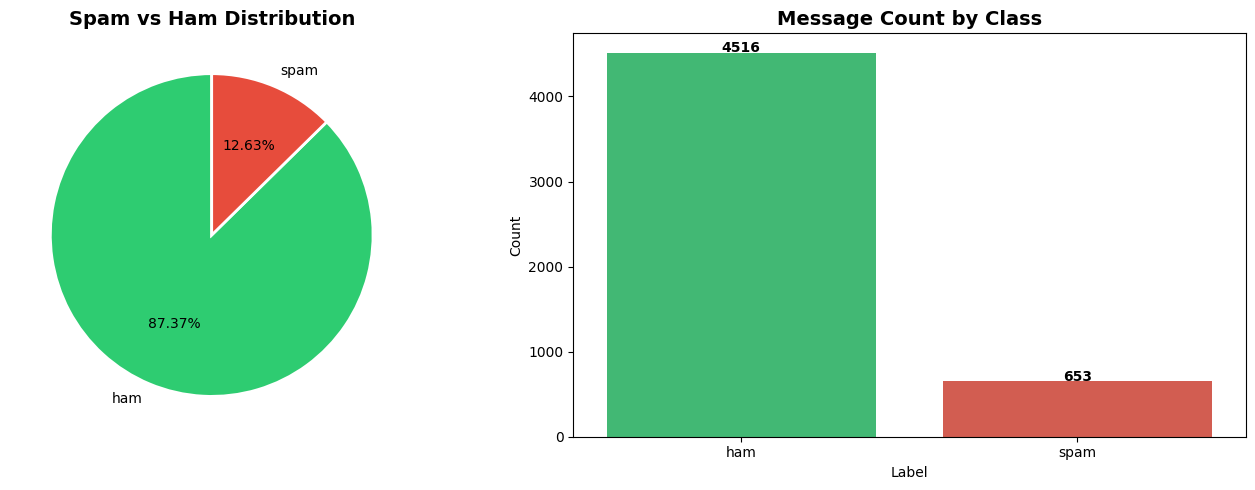

In [7]:
# Class distribution
print(df['target'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
counts = df['target'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%0.2f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Spam vs Ham Distribution', fontsize=14, fontweight='bold')

# Bar chart
sns.barplot(x=counts.index, y=counts.values, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Message Count by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')

# Feature engineering
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


,target,text,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [9]:
# Describe overall
print('Overall stats:')
df[['num_characters', 'num_words', 'num_sentences']].describe()

Overall stats:


,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [10]:
# Ham stats
print('Ham stats:')
df[df['target'] == 'ham'][['num_characters', 'num_words', 'num_sentences']].describe()

Ham stats:


,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [11]:
# Spam stats
print('Spam stats:')
df[df['target'] == 'spam'][['num_characters', 'num_words', 'num_sentences']].describe()

Spam stats:


,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


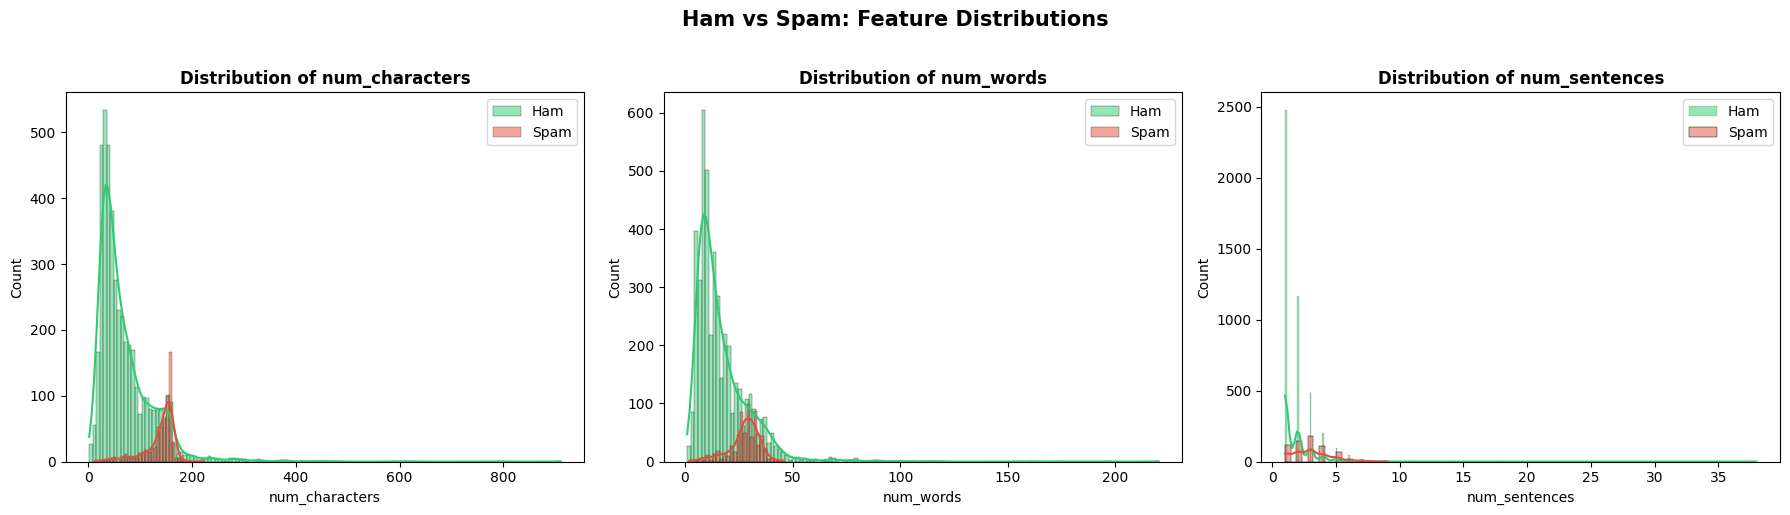

In [12]:
# Distribution plots: characters, words, sentences
features = ['num_characters', 'num_words', 'num_sentences']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, features):
    sns.histplot(df[df['target'] == 'ham'][feature], ax=ax, color='#2ecc71', label='Ham', kde=True)
    sns.histplot(df[df['target'] == 'spam'][feature], ax=ax, color='#e74c3c', label='Spam', kde=True)
    ax.set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    ax.legend()

plt.suptitle('Ham vs Spam: Feature Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

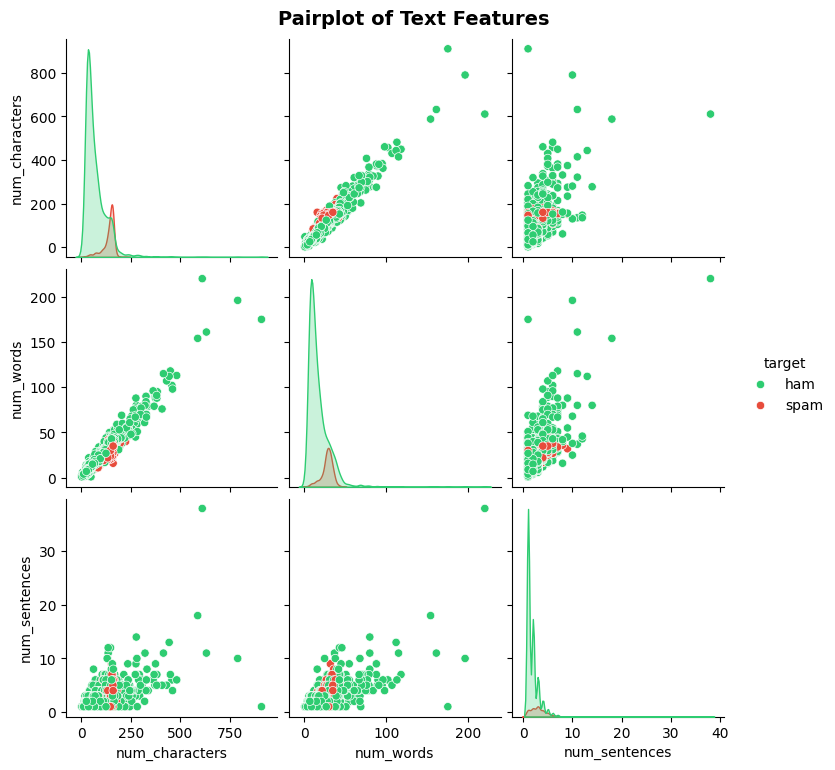

In [13]:
# Pairplot
sns.pairplot(df[['num_characters', 'num_words', 'num_sentences', 'target']], hue='target',
             palette={'ham': '#2ecc71', 'spam': '#e74c3c'})
plt.suptitle('Pairplot of Text Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## Step 5: Text Preprocessing

In [14]:
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)          # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)    # Remove special characters
    text = text.lower()                          # Lowercase
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]  # Remove stopwords
    words = [stemmer.stem(w) for w in words]     # Stemming
    return ' '.join(words)

df['cleaned_text'] = df['text'].apply(clean_text)
df[['text', 'cleaned_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,cleaned_text
0,"Go until jurong point, crazy.. Available only ...",jurong point crazi avail bugi great world buff...
1,Ok lar... Joking wif u oni...,lar joke wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win cup final tkt may tex...
3,U dun say so early hor... U c already then say...,dun say earli hor alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


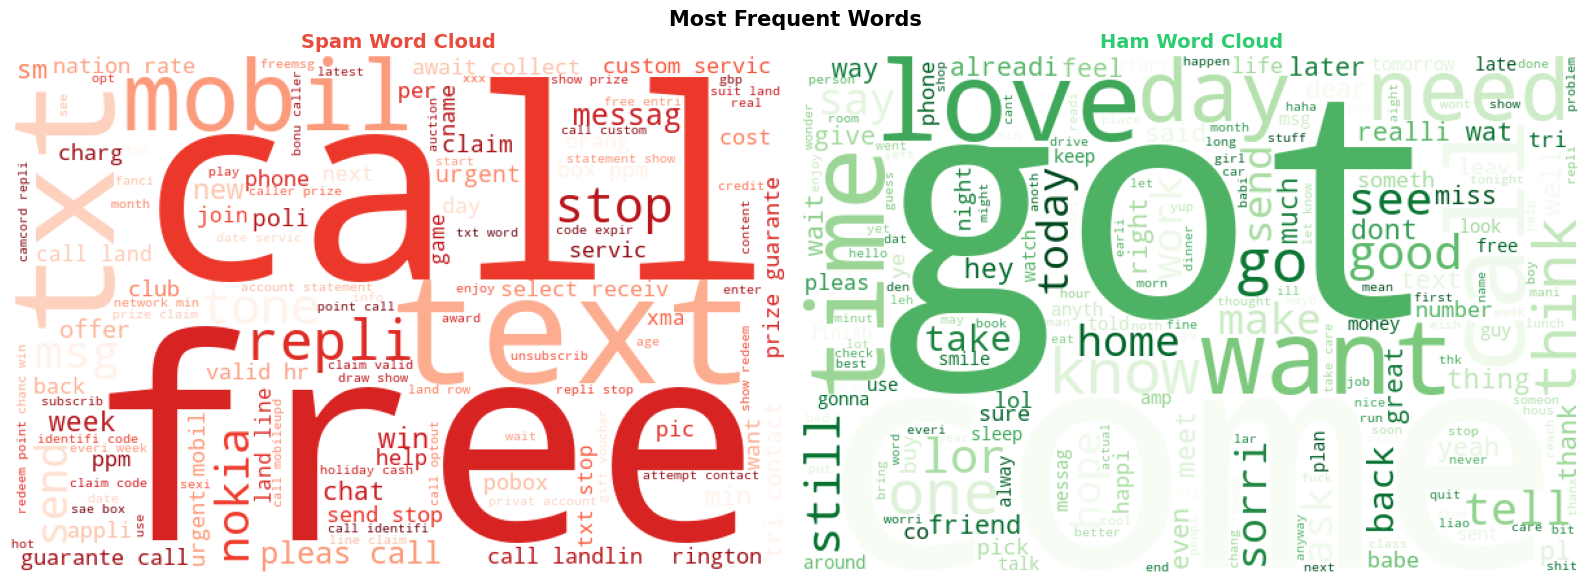

In [15]:
# Word Clouds
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc = WordCloud(width=600, height=400, min_font_size=10, background_color='white',
               colormap='Reds')
spam_wc = wc.generate(df[df['target'] == 'spam']['cleaned_text'].str.cat(sep=' '))
axes[0].imshow(spam_wc)
axes[0].axis('off')
axes[0].set_title('Spam Word Cloud', fontsize=14, fontweight='bold', color='#e74c3c')

wc2 = WordCloud(width=600, height=400, min_font_size=10, background_color='white',
                colormap='Greens')
ham_wc = wc2.generate(df[df['target'] == 'ham']['cleaned_text'].str.cat(sep=' '))
axes[1].imshow(ham_wc)
axes[1].axis('off')
axes[1].set_title('Ham Word Cloud', fontsize=14, fontweight='bold', color='#2ecc71')

plt.suptitle('Most Frequent Words', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

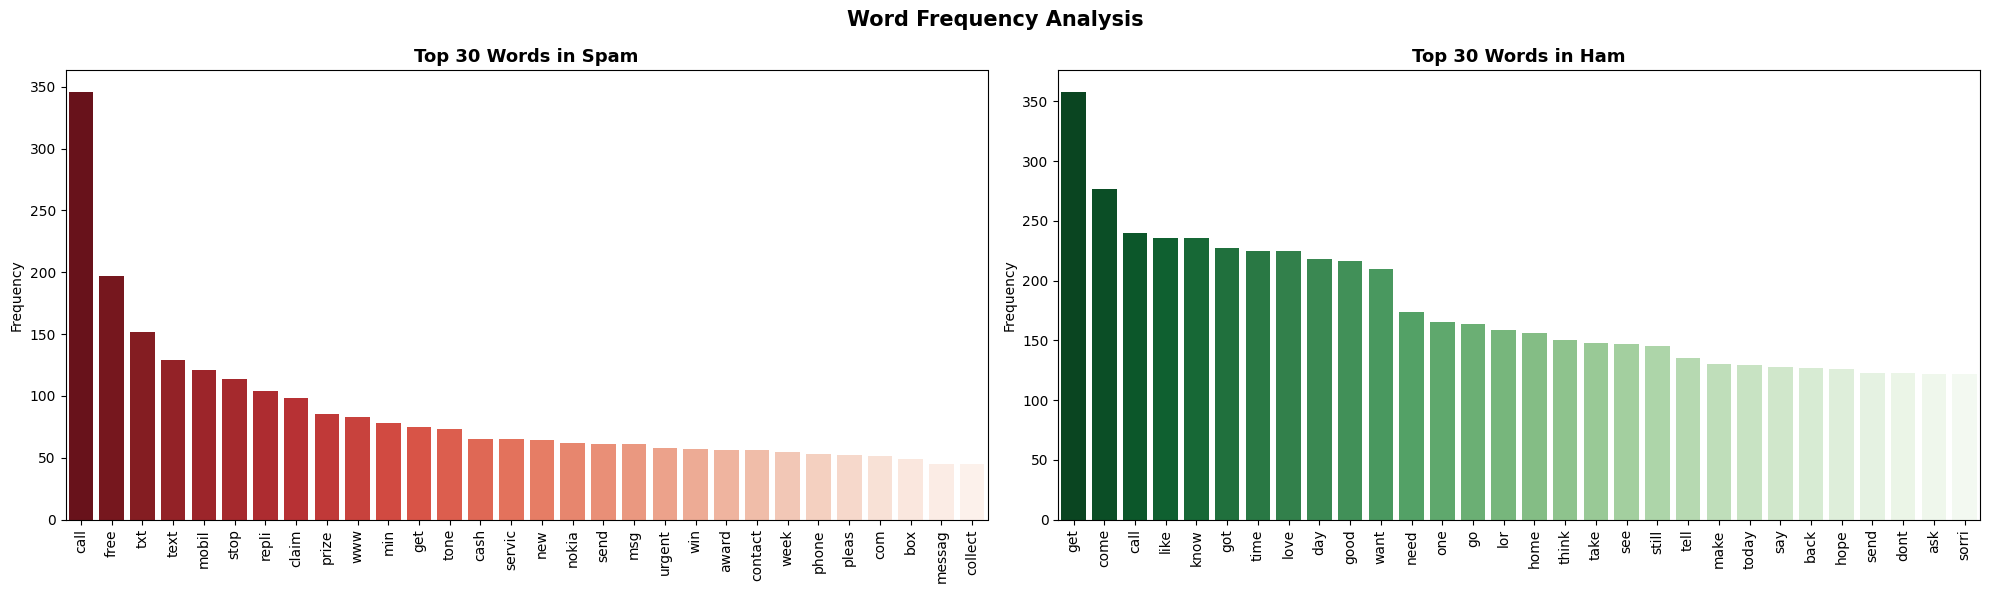

In [16]:
# Top 30 words - Spam vs Ham bar charts
spam_corpus = [word for msg in df[df['target'] == 'spam']['cleaned_text'] for word in msg.split()]
ham_corpus  = [word for msg in df[df['target'] == 'ham']['cleaned_text']  for word in msg.split()]

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Spam top 30
spam_common = Counter(spam_corpus).most_common(30)
sns.barplot(x=[w for w,_ in spam_common], y=[c for _,c in spam_common],
            palette='Reds_r', ax=axes[0])
axes[0].set_xticklabels([w for w,_ in spam_common], rotation=90)
axes[0].set_title('Top 30 Words in Spam', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Frequency')

# Ham top 30
ham_common = Counter(ham_corpus).most_common(30)
sns.barplot(x=[w for w,_ in ham_common], y=[c for _,c in ham_common],
            palette='Greens_r', ax=axes[1])
axes[1].set_xticklabels([w for w,_ in ham_common], rotation=90)
axes[1].set_title('Top 30 Words in Ham', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Frequency')

plt.suptitle('Word Frequency Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Balance Dataset

The dataset is imbalanced (many more ham than spam). We use **undersampling** to balance it.

In [17]:
print('Before balancing:')
print(df['target'].value_counts())

df_ham  = df[df['target'] == 'ham'].sample(653, random_state=42)
df_spam = df[df['target'] == 'spam'].sample(653, random_state=42)
df = pd.concat([df_ham, df_spam]).sample(frac=1, random_state=42).reset_index(drop=True)

print('\nAfter balancing:')
print(df['target'].value_counts())

Before balancing:
target
ham     4516
spam     653
Name: count, dtype: int64

After balancing:
target
spam    653
ham     653
Name: count, dtype: int64


## Step 7: Feature Extraction — TF-IDF Vectorization

| Technique | Best For |
|-----------|----------|
| Bag of Words | Short, simple text |
| **TF-IDF** | Short/medium text, spam/reviews ✅ |
| N-grams | Text where phrases matter |

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['cleaned_text'], df['target'], test_size=0.2, random_state=42
)

tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (1044, 1500)
Test shape: (262, 1500)


## Step 8: Model Training — Multinomial Naive Bayes

Why Naive Bayes?
- Fast and lightweight
- Works very well on text classification
- Handles high-dimensional sparse data efficiently

In [19]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB(alpha=0.5)
model.fit(X_train, y_train)

print('Model trained ✅')

Model trained ✅


## Step 9: Evaluation

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred) * 100, 2), '%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 91.6 %

Classification Report:
              precision    recall  f1-score   support

         ham       0.90      0.94      0.92       130
        spam       0.94      0.89      0.91       132

    accuracy                           0.92       262
   macro avg       0.92      0.92      0.92       262
weighted avg       0.92      0.92      0.92       262



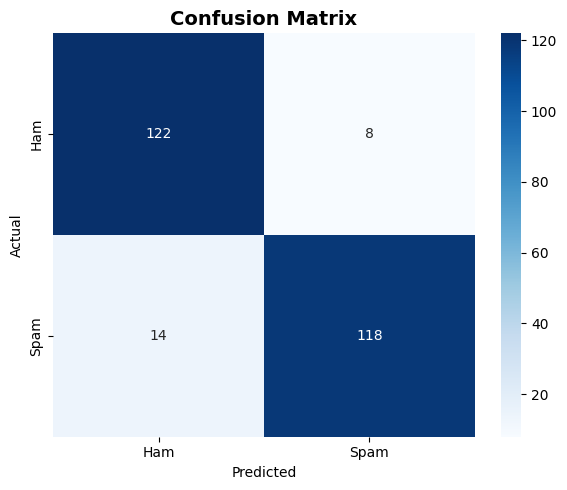

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 10: Save Model

In [22]:
pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))

print('Model and vectorizer saved ✅')

Model and vectorizer saved ✅


## Step 11: Prediction Function

In [23]:
def predict_spam(text):
    cleaned = clean_text(text)
    vector  = tfidf.transform([cleaned])
    result  = model.predict(vector)[0]
    return result

# Test it
test_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?"
]

for msg in test_messages:
    label = predict_spam(msg)
    icon = '🚨' if label == 'spam' else '✅'
    print(f"{icon} [{label.upper()}] {msg[:60]}...")

🚨 [SPAM] Congratulations! You've won a FREE iPhone. Click here to cla...
✅ [HAM] Hey, are we still meeting for lunch tomorrow?...


In [24]:
# Interactive test
user_input = input('Enter a message to check: ')
print('Prediction:', predict_spam(user_input))

Prediction: spam
